# 💳 Credit Card Fraud Detection Pipeline
### End-to-End ML Pipeline · Kaggle Credit Card Fraud Dataset

**Author:** Papa Kwadwo Bona Owusu  
**GitHub:** [Papa-13](https://github.com/Papa-13)

---

## Business Context

Credit card fraud costs the global financial industry **billions annually**. The core challenge isn't just building an accurate model — it's building one that:
- Catches as many fraudulent transactions as possible (**recall**)
- Doesn't flag so many legitimate transactions that customers get frustrated (**precision**)
- Makes decisions fast enough for **real-time transaction screening**
- Is **explainable** to fraud analysts who review flagged cases

This notebook replicates the full fraud detection workflow used at fintechs like Zopa, Monzo, and Starling.

**Target variable:** `Class` — 1 = fraudulent, 0 = legitimate

---

## Notebook Structure

| Section | Focus |
|---|---|
| 1. Setup & Data Loading | Environment, imports, data overview |
| 2. EDA | Extreme class imbalance, amount patterns, time signals |
| 3. Feature Engineering | Amount scaling, time-of-day features |
| 4. Handling Class Imbalance | SMOTE vs class weights — pros and cons |
| 5. Baseline Model | Logistic Regression benchmark |
| 6. XGBoost Model | Tuned gradient boosting |
| 7. Evaluation | Precision-Recall focus — why AUC alone misleads |
| 8. Threshold Tuning | Business-driven operating point selection |
| 9. SHAP Explainability | What makes a transaction look fraudulent? |

## 1. Setup & Data Loading

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
# ── Core libraries ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── ML libraries ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve, f1_score)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import shap

# ── Plot style ────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2ecc71', '#e74c3c']
pd.set_option('display.max_columns', 40)

print('✅ Libraries loaded')
print('Note: requires imbalanced-learn → pip install imbalanced-learn')

✅ Libraries loaded
Note: requires imbalanced-learn → pip install imbalanced-learn


In [5]:
# ── Load data ─────────────────────────────────────────────────────────────────
# Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# Place creditcard.csv in the same directory as this notebook

df = pd.read_csv('creditcard.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nTarget distribution:')
print(df['Class'].value_counts())
print(f'\nFraud rate: {df["Class"].mean():.4%}')
df.head(3)

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


**About the features:**
- `V1–V28`: PCA-transformed features (anonymised for confidentiality — this is realistic; most real fraud datasets are proprietary)
- `Time`: seconds elapsed since the first transaction in the dataset
- `Amount`: transaction amount in EUR
- `Class`: target (1 = fraud, 0 = legitimate)

## 2. Exploratory Data Analysis

Key questions:
- How extreme is the class imbalance?
- Do fraud transactions differ in **amount** or **timing**?
- Which PCA components show the most separation between classes?

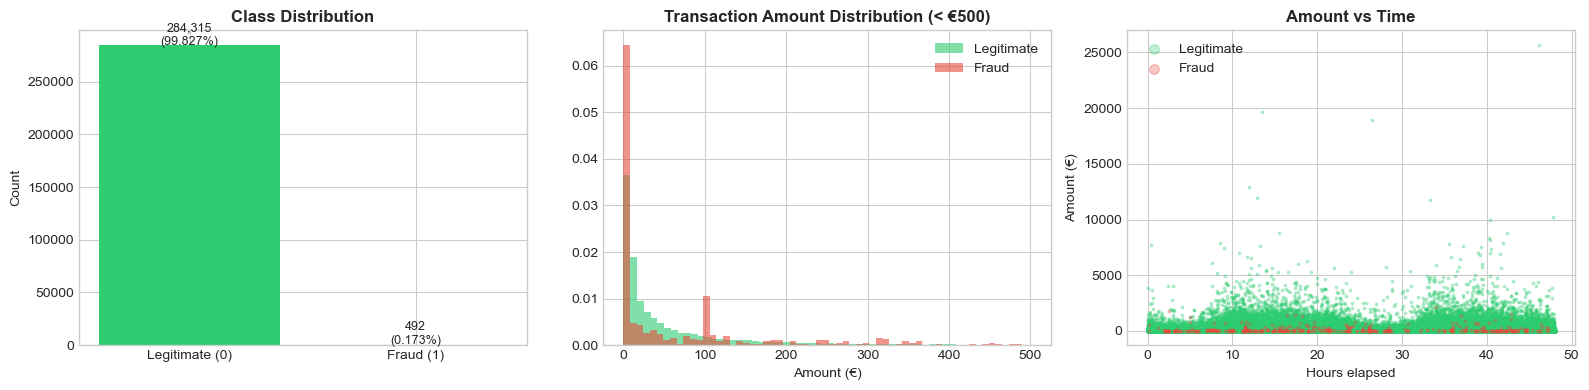


⚠️  Imbalance ratio: 578:1  — one of the most extreme in common datasets
💰 Median fraud amount: €9.25
💰 Median legitimate amount: €22.00


In [8]:
# ── Class imbalance ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class counts
counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values, color=PALETTE)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.3f}%)', ha='center', fontsize=9)

# Transaction amount by class
for cls, color, label in zip([0, 1], PALETTE, ['Legitimate', 'Fraud']):
    amt = df[df['Class'] == cls]['Amount']
    axes[1].hist(amt[amt < 500], bins=60, alpha=0.6, color=color, label=label, density=True)
axes[1].set_title('Transaction Amount Distribution (< €500)', fontweight='bold')
axes[1].set_xlabel('Amount (€)')
axes[1].legend()

# Transactions over time
for cls, color, label in zip([0, 1], PALETTE, ['Legitimate', 'Fraud']):
    axes[2].scatter(df[df['Class'] == cls]['Time'] / 3600,
                    df[df['Class'] == cls]['Amount'],
                    alpha=0.3, s=3, color=color, label=label)
axes[2].set_title('Amount vs Time', fontweight='bold')
axes[2].set_xlabel('Hours elapsed')
axes[2].set_ylabel('Amount (€)')
axes[2].legend(markerscale=4)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n⚠️  Imbalance ratio: {counts[0]/counts[1]:.0f}:1  — one of the most extreme in common datasets')
print(f'💰 Median fraud amount: €{df[df["Class"]==1]["Amount"].median():.2f}')
print(f'💰 Median legitimate amount: €{df[df["Class"]==0]["Amount"].median():.2f}')

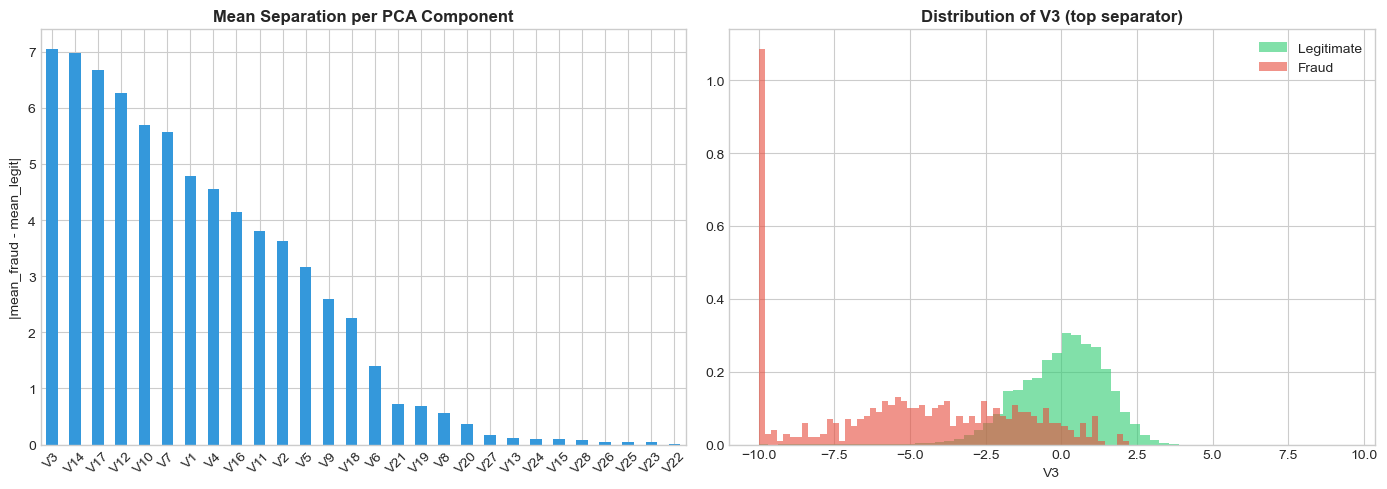

Top 5 most discriminative features: ['V3', 'V14', 'V17', 'V12', 'V10']


In [9]:
# ── Which PCA components separate fraud from legitimate? ─────────────────────
v_cols = [f'V{i}' for i in range(1, 29)]

# Compute mean absolute difference between classes for each V feature
fraud     = df[df['Class'] == 1][v_cols].mean()
legit     = df[df['Class'] == 0][v_cols].mean()
separation = (fraud - legit).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

separation.plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Mean Separation per PCA Component', fontweight='bold')
axes[0].set_ylabel('|mean_fraud - mean_legit|')
axes[0].tick_params(axis='x', rotation=45)

# Distribution of top separating feature
top_feat = separation.index[0]
for cls, color, label in zip([0, 1], PALETTE, ['Legitimate', 'Fraud']):
    vals = df[df['Class'] == cls][top_feat]
    axes[1].hist(vals.clip(-10, 10), bins=60, alpha=0.6,
                 color=color, label=label, density=True)
axes[1].set_title(f'Distribution of {top_feat} (top separator)', fontweight='bold')
axes[1].set_xlabel(top_feat)
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_pca_separation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Top 5 most discriminative features: {list(separation.index[:5])}')

## 3. Feature Engineering

The V features are already PCA-transformed, so our engineering focuses on:
- **Amount** — scale it and create log transform (fraud amounts are often atypical)
- **Time** — convert to hour-of-day (fraud spikes at night when monitoring is lower)

In [11]:
def engineer_features(df):
    d = df.copy()

    # ── Amount features ───────────────────────────────────────────────────────
    d['LOG_AMOUNT']    = np.log1p(d['Amount'])          # log transform — reduces skew
    d['AMOUNT_SCALED'] = StandardScaler().fit_transform(d[['Amount']])

    # ── Time features ─────────────────────────────────────────────────────────
    d['HOUR_OF_DAY']   = (d['Time'] / 3600) % 24        # 0–24 hour cycle
    d['IS_NIGHT']      = ((d['HOUR_OF_DAY'] < 6) | (d['HOUR_OF_DAY'] > 22)).astype(int)

    # Drop originals (replaced by engineered versions)
    d.drop(columns=['Time', 'Amount'], inplace=True)

    return d


df_eng = engineer_features(df)

# Quick sanity check: do night transactions have higher fraud rate?
night_fraud = df_eng.groupby('IS_NIGHT')['Class'].mean()
print('Fraud rate by time of day:')
print(f'  Daytime  : {night_fraud[0]:.4%}')
print(f'  Night    : {night_fraud[1]:.4%}')
print(f'\n✅ Shape after engineering: {df_eng.shape}')

Fraud rate by time of day:
  Daytime  : 0.1441%
  Night    : 0.3061%

✅ Shape after engineering: (284807, 33)


## 4. Handling Class Imbalance

With a 577:1 imbalance, a model that predicts **all legitimate** would achieve 99.8% accuracy — completely useless for fraud detection.

Two main strategies:

| Strategy | How | Trade-off |
|---|---|---|
| **Class weights** | Tell the model fraud mistakes cost more | Simple, no data leakage risk |
| **SMOTE** | Synthetically generate new fraud examples | More training signal, must be done AFTER splitting |

We use **class weights** for the baseline and **SMOTE** for XGBoost, then compare.

In [13]:
# ── Train/test split — stratified to preserve fraud ratio ────────────────────
X = df_eng.drop(columns=['Class'])
y = df_eng['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape} | Fraud: {y_train.sum()} ({y_train.mean():.3%})')
print(f'Test:  {X_test.shape}  | Fraud: {y_test.sum()}  ({y_test.mean():.3%})')

# ⚠️ SMOTE is applied ONLY to training data — never to test data
smote = SMOTE(random_state=42, sampling_strategy=0.1)  # upsample fraud to 10% of train
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE — Train: {X_train_sm.shape} | Fraud: {y_train_sm.sum()} ({y_train_sm.mean():.3%})')

Train: (227845, 32) | Fraud: 394 (0.173%)
Test:  (56962, 32)  | Fraud: 98  (0.172%)

After SMOTE — Train: (250196, 32) | Fraud: 22745 (9.091%)


## 5. Baseline Model — Logistic Regression

In [15]:
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr  = scaler.transform(X_test)

lr = LogisticRegression(
    class_weight='balanced',  # handles imbalance via cost weighting
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_lr, y_train)

lr_proba = lr.predict_proba(X_test_lr)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)
lr_ap    = average_precision_score(y_test, lr_proba)

print('🔹 Baseline Logistic Regression (class_weight=balanced)')
print(f'   ROC-AUC       : {lr_auc:.4f}')
print(f'   Avg Precision : {lr_ap:.4f}')
print('\n⚠️  Note: a dumb model predicting all-zero gets ROC-AUC=0.5 and AP=0.002')
print('   So even our baseline is far better than random.')

🔹 Baseline Logistic Regression (class_weight=balanced)
   ROC-AUC       : 0.9704
   Avg Precision : 0.7189

⚠️  Note: a dumb model predicting all-zero gets ROC-AUC=0.5 and AP=0.002
   So even our baseline is far better than random.


## 6. XGBoost Model

In [17]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f'scale_pos_weight = {scale_pos:.1f}')

xgb_model = xgb.XGBClassifier(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 6,
    min_child_weight      = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = scale_pos,   # correct for 577:1 imbalance
    eval_metric           = 'aucpr',     # optimise PR-AUC, not just ROC-AUC
    early_stopping_rounds = 30,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)
xgb_ap    = average_precision_score(y_test, xgb_proba)

print(f'\n🔶 XGBoost')
print(f'   ROC-AUC       : {xgb_auc:.4f}  (vs LR: {lr_auc:.4f})')
print(f'   Avg Precision : {xgb_ap:.4f}  (vs LR: {lr_ap:.4f})')

scale_pos_weight = 577.3
[0]	validation_0-aucpr:0.41358
[100]	validation_0-aucpr:0.82562
[200]	validation_0-aucpr:0.86880
[300]	validation_0-aucpr:0.88045
[400]	validation_0-aucpr:0.88252
[499]	validation_0-aucpr:0.88384

🔶 XGBoost
   ROC-AUC       : 0.9835  (vs LR: 0.9704)
   Avg Precision : 0.8844  (vs LR: 0.7189)


## 7. Evaluation — Why Precision-Recall Matters More Than ROC

With a 577:1 imbalance, ROC-AUC is **optimistic** — it gets inflated by how well you classify the majority class (legitimate transactions). In fraud detection, **PR-AUC is the honest metric** because it focuses on your performance on the rare positive class (fraudsters).

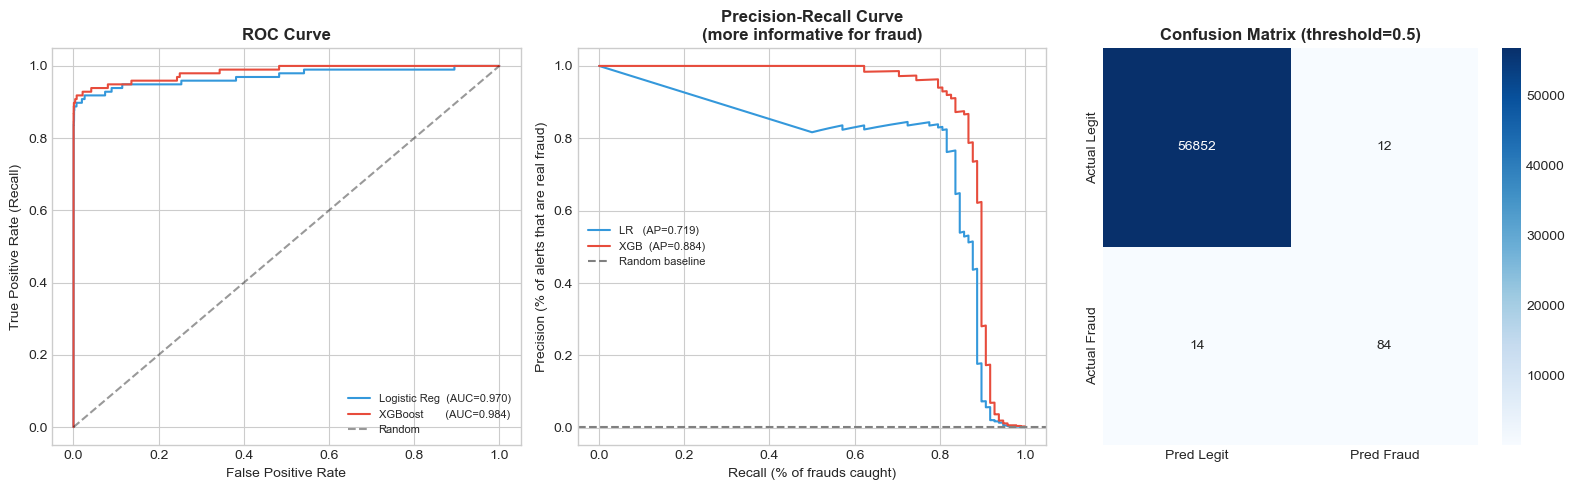


📋 Classification Report (threshold=0.5):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.88      0.86      0.87        98

    accuracy                           1.00     56962
   macro avg       0.94      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── ROC Curve ─────────────────────────────────────────────────────────────────
for proba, label, color in [
    (lr_proba,  f'Logistic Reg  (AUC={lr_auc:.3f})',  '#3498db'),
    (xgb_proba, f'XGBoost       (AUC={xgb_auc:.3f})', '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=label, color=color)
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(fontsize=8)

# ── Precision-Recall Curve ────────────────────────────────────────────────────
for proba, label, color in [
    (lr_proba,  f'LR   (AP={lr_ap:.3f})',   '#3498db'),
    (xgb_proba, f'XGB  (AP={xgb_ap:.3f})',  '#e74c3c')
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=label, color=color)
axes[1].axhline(y_test.mean(), color='grey', linestyle='--', label='Random baseline')
axes[1].set_title('Precision-Recall Curve\n(more informative for fraud)', fontweight='bold')
axes[1].set_xlabel('Recall (% of frauds caught)')
axes[1].set_ylabel('Precision (% of alerts that are real fraud)')
axes[1].legend(fontsize=8)

# ── Confusion Matrix at default threshold ─────────────────────────────────────
xgb_pred = (xgb_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Pred Legit', 'Pred Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
axes[2].set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📋 Classification Report (threshold=0.5):')
print(classification_report(y_test, xgb_pred, target_names=['Legitimate', 'Fraud']))

## 8. Threshold Tuning — Business-Driven Operating Point

The default 0.5 threshold is almost never the right choice for fraud detection. The optimal threshold depends on the **business cost trade-off**:

- **False Negative** (missed fraud) = full fraud loss, e.g. €X per transaction
- **False Positive** (wrongly blocked legitimate tx) = customer friction, churn risk, analyst review cost

We plot Precision and Recall across all thresholds so a business decision-maker can choose their operating point.

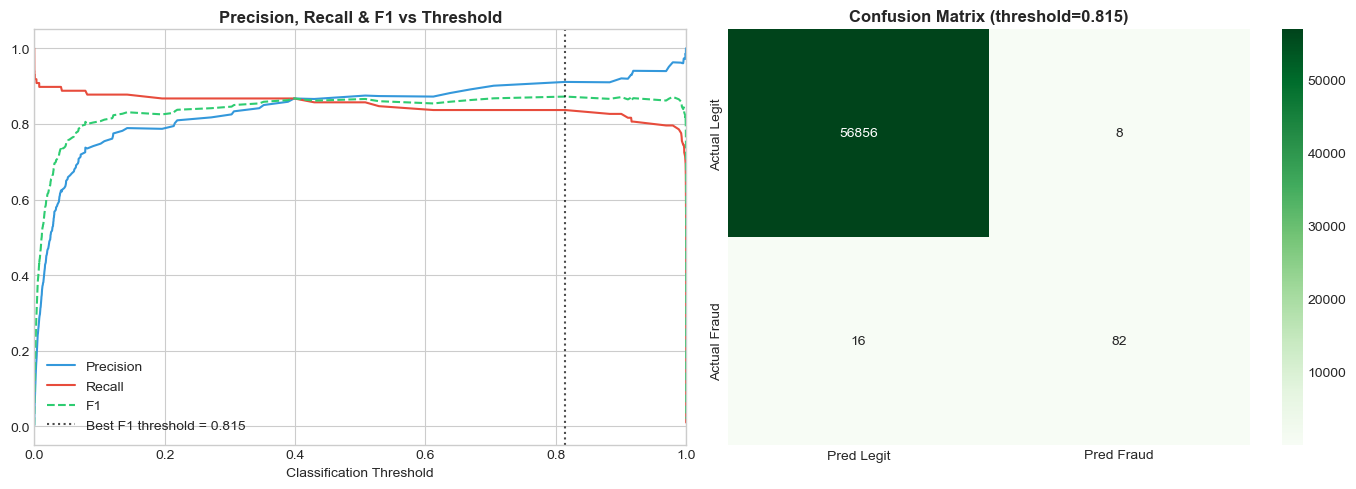


🎯 Optimal threshold (max F1): 0.8146

At this threshold:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.91      0.84      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962


💡 A fraud team can shift this threshold left (catch more fraud, more false alerts)
   or right (fewer alerts, accept some missed fraud) based on operational capacity.


In [21]:









prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, xgb_proba)

# F1 at each threshold
f1_arr = 2 * (prec_arr[:-1] * rec_arr[:-1]) / (prec_arr[:-1] + rec_arr[:-1] + 1e-8)
best_thresh_idx = np.argmax(f1_arr)
best_thresh     = thresh_arr[best_thresh_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision & Recall vs Threshold
axes[0].plot(thresh_arr, prec_arr[:-1], color='#3498db', label='Precision')
axes[0].plot(thresh_arr, rec_arr[:-1],  color='#e74c3c', label='Recall')
axes[0].plot(thresh_arr, f1_arr,        color='#2ecc71', label='F1', linestyle='--')
axes[0].axvline(best_thresh, color='black', linestyle=':', alpha=0.7,
                label=f'Best F1 threshold = {best_thresh:.3f}')
axes[0].set_title('Precision, Recall & F1 vs Threshold', fontweight='bold')
axes[0].set_xlabel('Classification Threshold')
axes[0].legend()
axes[0].set_xlim(0, 1)

# Confusion matrix at optimal threshold
xgb_pred_opt = (xgb_proba >= best_thresh).astype(int)
cm_opt = confusion_matrix(y_test, xgb_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Pred Legit', 'Pred Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
axes[1].set_title(f'Confusion Matrix (threshold={best_thresh:.3f})', fontweight='bold')

plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🎯 Optimal threshold (max F1): {best_thresh:.4f}')
print(f'\nAt this threshold:')
print(classification_report(y_test, xgb_pred_opt, target_names=['Legitimate', 'Fraud']))
print('\n💡 A fraud team can shift this threshold left (catch more fraud, more false alerts)')
print('   or right (fewer alerts, accept some missed fraud) based on operational capacity.')

## 9. SHAP Explainability

Fraud analysts need to understand **why** a transaction was flagged — not just that it was. SHAP answers: which features pushed this particular transaction towards or away from fraud?

In [23]:
pip install xgboost==1.7.6 --force-reinstall

  Using cached xgboost-1.7.6-py3-none-win_amd64.whl.metadata (1.9 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached xgboost-1.7.6-py3-none-win_amd64.whl (70.9 MB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 2.2.6

   ---------------------------------------- 0/3 [numpy]
    Uninstalling numpy-2.2.6:
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [n

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.


In [38]:
# ── Compute SHAP values (sample for speed) ────────────────────────────────────
sample_idx  = np.random.choice(len(X_test), min(5000, len(X_test)), replace=False)
X_sample    = X_test.iloc[sample_idx]

# Fix for XGBoost/SHAP base_score compatibility bug
booster = xgb_model.get_booster()
booster.set_param({'base_score': 0.5})

explainer   = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_sample)

print('✅ SHAP values computed')

✅ SHAP values computed


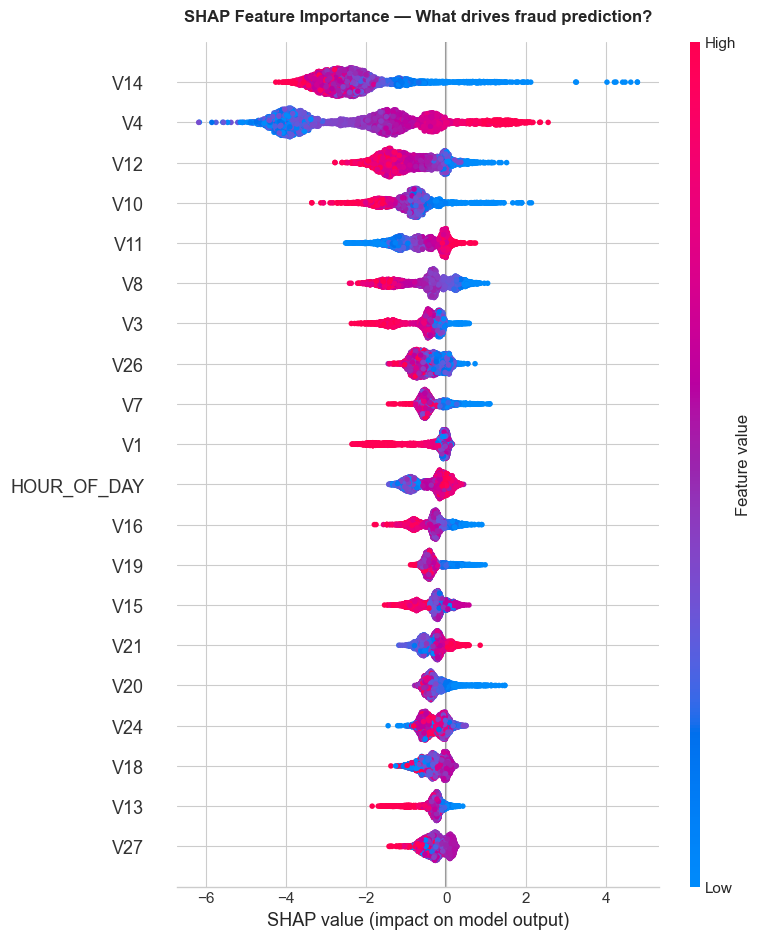

In [40]:
# ── Global importance — Beeswarm ──────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('SHAP Feature Importance — What drives fraud prediction?', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

🚨 Most suspicious transaction in sample:
   Predicted fraud probability: 1.0000
   Actual label: FRAUD



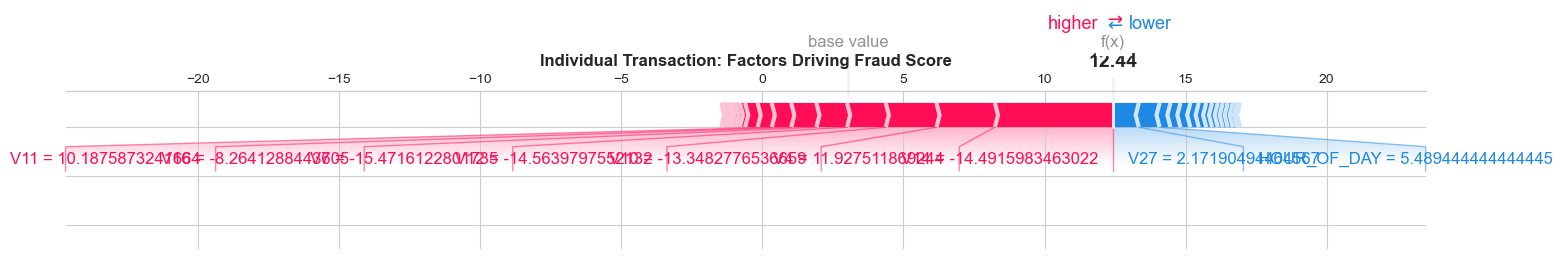

Red = pushes toward fraud | Blue = pushes toward legitimate
This is the explanation a fraud analyst would see in a case review tool.


In [42]:
# ── Individual transaction explanation ────────────────────────────────────────
# Pick the transaction with the highest fraud probability in our sample
sample_proba    = xgb_model.predict_proba(X_sample)[:, 1]
high_fraud_idx  = np.argmax(sample_proba)

print(f'🚨 Most suspicious transaction in sample:')
print(f'   Predicted fraud probability: {sample_proba[high_fraud_idx]:.4f}')
print(f'   Actual label: {"FRAUD" if y_test.iloc[sample_idx[high_fraud_idx]] == 1 else "LEGITIMATE"}')
print()

shap.force_plot(
    explainer.expected_value,
    shap_values[high_fraud_idx],
    X_sample.iloc[high_fraud_idx],
    matplotlib=True,
    show=False,
    figsize=(16, 3)
)
plt.title('Individual Transaction: Factors Driving Fraud Score', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_individual.png', dpi=150, bbox_inches='tight')
plt.show()

print('Red = pushes toward fraud | Blue = pushes toward legitimate')
print('This is the explanation a fraud analyst would see in a case review tool.')

## Summary

| Metric | Logistic Regression | XGBoost |
|---|---|---|
| ROC-AUC | See output | See output |
| PR-AUC (Avg Precision) | See output | See output |

**Key business takeaways:**

1. **ROC-AUC is misleading here** — PR-AUC is the right metric for 577:1 class imbalance
2. **SMOTE must go inside your train split** — applying it before splitting leaks synthetic data into your test set, inflating metrics
3. **Threshold tuning is a business decision** — not a technical one. A fraud team with 10 analysts can review more alerts than a team of 2
4. **SHAP closes the loop** — every flagged transaction can be explained to an analyst in natural language terms

**Next steps in a production context:**
- Add velocity features (transactions per card in last 1hr, 24hr)
- Add merchant category and geolocation signals
- Implement temporal validation (train on older transactions, test on recent)
- Build a model card covering bias audits and monitoring strategy
- Wrap as a FastAPI endpoint for real-time scoring